<a href="https://colab.research.google.com/github/nishita-ds/pyTorch-learning/blob/main/10-hyperparameter-tuning-using-optuna/ann_fashion_mnist_pytorch_gpu_optimized_optuna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [49]:
# check GPU availability
device=torch.device("cuda" if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [33]:
!pip install torch.utils

  Preparing metadata (setup.py) ... done
  Created wheel for torch.utils: filename=torch_utils-0.1.2-py3-none-any.whl size=6188 sha256=41f88d6f6fbc456882a4bc77f36fa9baaa187b8aafc36763ff9d8f832e73e748
  Stored in directory: /root/.cache/pip/wheels/4e/06/32/1d26da91e30177d171ecb60995273ad8709ca2b6ce66ccefa7
Successfully built torch.utils


In [50]:
# Set random seeds for reproducibility
torch.manual_seed(42)

In [51]:
df=pd.read_csv('fashion-mnist_train.csv.zip')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [52]:
df.shape

(60000, 785)

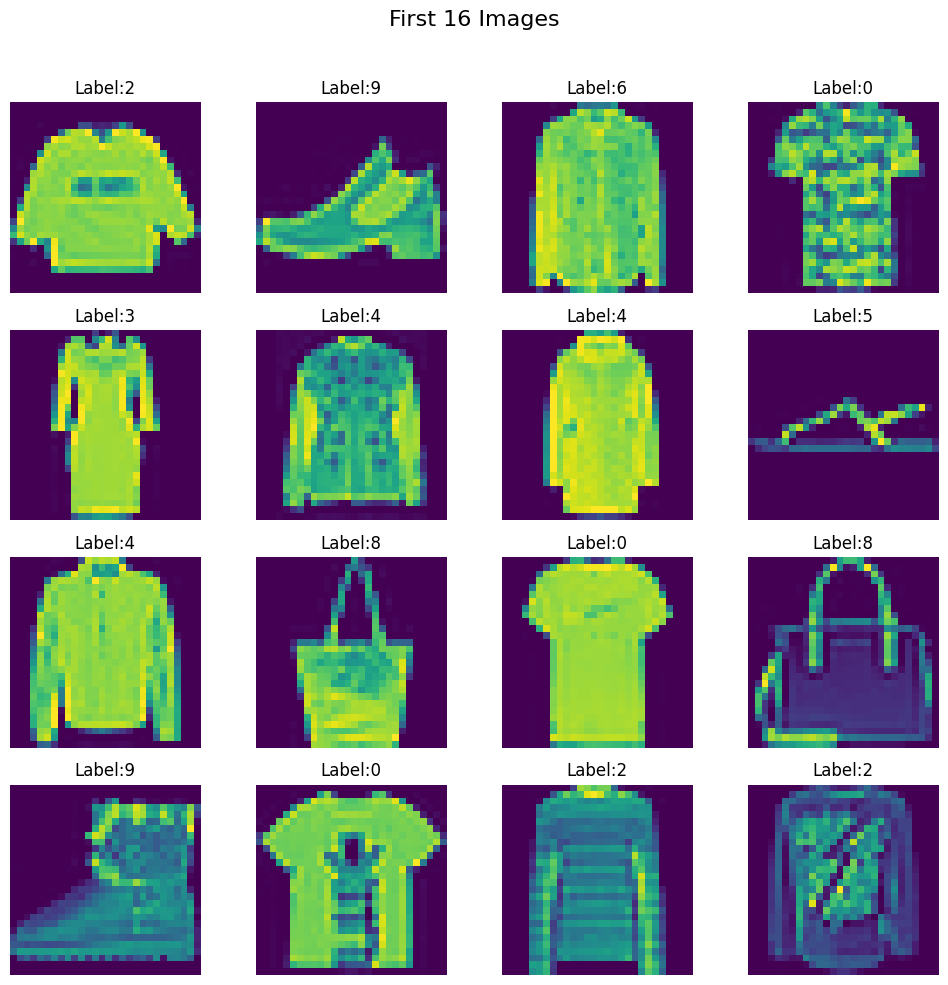

In [53]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images",fontsize=16)

# Plot the first 16 Images from the dataset
for i,ax in enumerate(axes.flat):
    img=df.iloc[i,1:].values.reshape(28,28)
    ax.imshow(img) #display in grayscale
    ax.axis('off')  #remove axis for a cleaner look
    ax.set_title(f"Label:{df.iloc[i,0]}") #show the label

plt.tight_layout(rect=[0,0,1,0.96])  #Adjust layout to fit the title
plt.show()

In [54]:
# train test split
X=df.iloc[:,1:].values
y=df.iloc[:,0].values

In [55]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [56]:
# scaling the features
x_train=x_train/255.0
x_test=x_test/255.0

In [57]:
x_train

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.00392157, 0.        ,
        0.        ]])

In [58]:
# create CustomDataset Class
class CustomDataset(Dataset):

  def __init__(self,features,labels):

    self.features=torch.tensor(features,dtype=torch.float32)
    self.labels=torch.tensor(labels,dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):

    return self.features[index],self.labels[index]


In [59]:
# create train_dataset_object
train_dataset=CustomDataset(x_train,y_train)
test_dataset=CustomDataset(x_test,y_test)

In [60]:
len(train_dataset)

48000

In [61]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.2275,
         0.5333, 0.0000, 0.0

In [62]:
len(train_dataset)

48000

In [66]:
class MyNN(nn.Module):

  def __init__(self,input_dim,output_dim,num_hidden_layers,neurons_per_layer,dropout_rate):
    super().__init__()

    layers=[]

    for i in range(num_hidden_layers):
      layers.append(nn.Linear(input_dim,neurons_per_layer))
      layers.append(nn.BatchNorm1d(neurons_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(dropout_rate))
      input_dim=neurons_per_layer

    layers.append(nn.Linear(neurons_per_layer,output_dim))

    self.model=nn.Sequential(*layers)  #unpacking list using asterisk

  def forward(self,x):
    return self.model(x)

# objective function
def objective(trial):

# next hyperparameter values from the search space
  num_hidden_layers=trial.suggest_int("num_hidden_layers",1,5)
  neurons_per_layer=trial.suggest_int("neurons_per_layer",8,128,step=8)
  epochs=trial.suggest_int("epochs",10,50,step=10)
  learning_rate=trial.suggest_float("learning_rate",1e-5,1e-1,log=True)
  dropout_rate=trial.suggest_float("dropout_rate",0.1,0.5,step=0.1)
  batch_size=trial.suggest_categorical("batch_size",[16,32,64,128])
  optimizer_name=trial.suggest_categorical("optimizer",["Adam","SGD","RMSprop"])
  weight_decay=trial.suggest_float("weight_decay",1e-5,1e-3,log=True)


# create train and test loader
  train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True,pin_memory=True)
  test_loader=DataLoader(test_dataset,batch_size=batch_size,shuffle=False,pin_memory=True)
# model init
  input_dim=784
  output_dim=10

  model=MyNN(input_dim,output_dim,num_hidden_layers,neurons_per_layer,dropout_rate)
  model.to(device)


# optimizer selection
# loss function
  criterion=nn.CrossEntropyLoss()
# optimizer
  if optimizer_name=="Adam":
    optimizer=optim.Adam(model.parameters(),lr=learning_rate,weight_decay=weight_decay)

  elif optimizer_name=="RMSprop":
    optimizer=optim.RMSprop(model.parameters(),lr=learning_rate,weight_decay=weight_decay)

  else:
    optimizer=optim.SGD(model.parameters(),lr=learning_rate,weight_decay=weight_decay)


# training loop

  for epoch in range(epochs):

    for batch_features,batch_labels in train_loader:
      #move the data to gpu
      batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)

      # forward pass
      outputs=model(batch_features)

      # calculate loss
      loss=criterion(outputs,batch_labels)

      # back pass
      optimizer.zero_grad()
      loss.backward()

      # update grads
      optimizer.step()


  # evaluation
  model.eval()

  total=0
  correct=0

  with torch.no_grad():
    for batch_features,batch_labels in test_loader:
      #move the data to gpu
      batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)
      outputs=model(batch_features)
      _,predicted=torch.max(outputs.data,1)
      total+=batch_labels.shape[0]

      correct+=(predicted==batch_labels).sum().item()

    accuracy=(correct/total)

  return accuracy

In [19]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 19.6 MB/s eta 0:00:00


In [67]:
import optuna
study=optuna.create_study(direction='maximize')
# study.optimize(objective,n_trials=10)

[I 2026-04-08 12:29:43,471] A new study created in memory with name: no-name-f2758ec5-a18b-4a90-9e0b-e85b10a35729


In [68]:
study.optimize(objective,n_trials=10)

[I 2026-04-08 12:30:48,263] Trial 0 finished with value: 0.7595 and parameters: {'num_hidden_layers': 5, 'neurons_per_layer': 64, 'epochs': 20, 'learning_rate': 0.012333352549869527, 'dropout_rate': 0.4, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 0.0005865687481807616}. Best is trial 0 with value: 0.7595.
[I 2026-04-08 12:33:41,327] Trial 1 finished with value: 0.6979166666666666 and parameters: {'num_hidden_layers': 3, 'neurons_per_layer': 16, 'epochs': 20, 'learning_rate': 0.06174210053030358, 'dropout_rate': 0.2, 'batch_size': 16, 'optimizer': 'Adam', 'weight_decay': 1.6161221130215816e-05}. Best is trial 0 with value: 0.7595.
[I 2026-04-08 12:35:26,654] Trial 2 finished with value: 0.8924166666666666 and parameters: {'num_hidden_layers': 4, 'neurons_per_layer': 112, 'epochs': 20, 'learning_rate': 0.0001445873806411048, 'dropout_rate': 0.2, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.0002626913169238254}. Best is trial 2 with value: 0.8924166666666666.
[I

In [69]:
study.best_value

0.8924166666666666

In [70]:
study.best_params

{'num_hidden_layers': 4,
 'neurons_per_layer': 112,
 'epochs': 20,
 'learning_rate': 0.0001445873806411048,
 'dropout_rate': 0.2,
 'batch_size': 32,
 'optimizer': 'Adam',
 'weight_decay': 0.0002626913169238254}